Note: you may need to restart the kernel to use updated packages.
Processando dados da Tesla...



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip



--- Primeiras linhas da Tesla (Stock Data) ---
                       Date      Open      High       Low     Close  \
0 2010-06-29 00:00:00-04:00  1.266667  1.666667  1.169333  1.592667   
1 2010-06-30 00:00:00-04:00  1.719333  2.028000  1.553333  1.588667   
2 2010-07-01 00:00:00-04:00  1.666667  1.728000  1.351333  1.464000   
3 2010-07-02 00:00:00-04:00  1.533333  1.540000  1.247333  1.280000   
4 2010-07-06 00:00:00-04:00  1.333333  1.333333  1.055333  1.074000   

      Volume  Dividends  Stock Splits  
0  281494500        0.0           0.0  
1  257806500        0.0           0.0  
2  123282000        0.0           0.0  
3   77097000        0.0           0.0  
4  103003500        0.0           0.0  

--- Últimas linhas da Tesla (Revenue) ---
          Date Revenue
48  2010-09-30      31
49  2010-06-30      28
50  2010-03-31      21
52  2009-09-30      46
53  2009-06-30      27


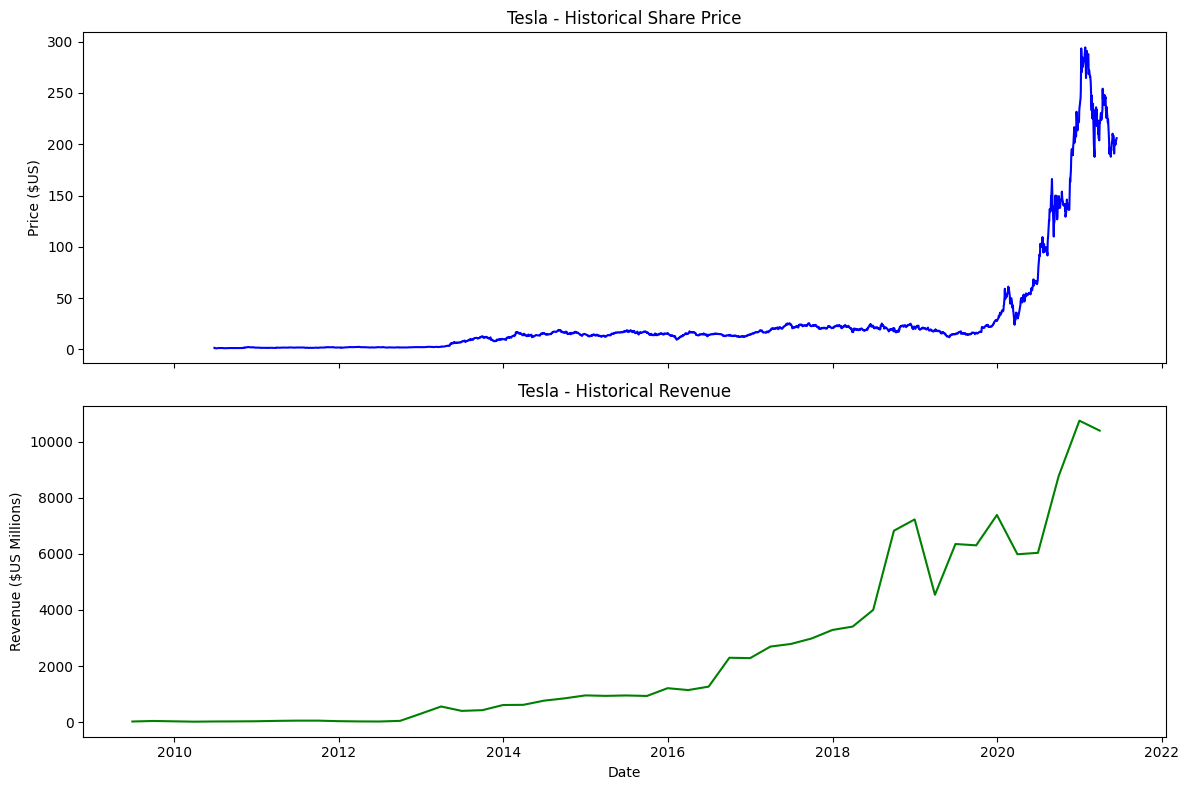

Processando dados da GameStop...

--- Primeiras linhas da GameStop (Stock Data) ---
                       Date      Open      High       Low     Close    Volume  \
0 2002-02-13 00:00:00-05:00  1.620129  1.693350  1.603296  1.691667  76216000   
1 2002-02-14 00:00:00-05:00  1.712707  1.716074  1.670626  1.683250  11021600   
2 2002-02-15 00:00:00-05:00  1.683250  1.687458  1.658002  1.674834   8389600   
3 2002-02-19 00:00:00-05:00  1.666417  1.666417  1.578047  1.607504   7410400   
4 2002-02-20 00:00:00-05:00  1.615920  1.662209  1.603296  1.662209   6892800   

   Dividends  Stock Splits  
0        0.0           0.0  
1        0.0           0.0  
2        0.0           0.0  
3        0.0           0.0  
4        0.0           0.0  

--- Últimas linhas da GameStop (Revenue) ---
          Date Revenue
57  2006-01-31    1667
58  2005-10-31     534
59  2005-07-31     416
60  2005-04-30     475
61  2005-01-31     709


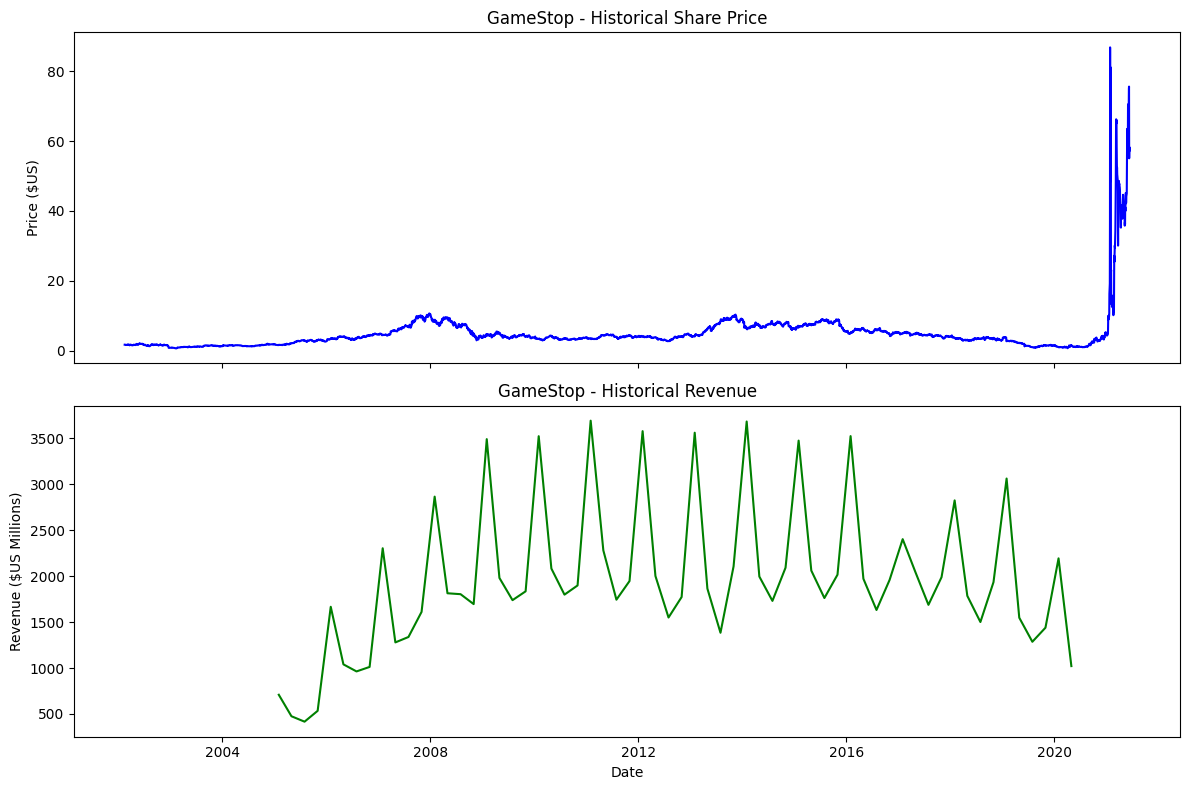

In [3]:
# %% [markdown]
# ### Célula 1: Instalação das bibliotecas necessárias
# %%
%pip install yfinance pandas requests bs4 lxml html5lib matplotlib

# %% [markdown]
# ### Célula 2: Importações e Configurações
# %%
import yfinance as yf
import pandas as pd
import requests
from bs4 import BeautifulSoup
import matplotlib.pyplot as plt
import warnings
import io

# Ignorar avisos de depreciação do Pandas para deixar a saída limpa
warnings.filterwarnings("ignore", category=FutureWarning)

# %% [markdown]
# ### Célula 3: Definição da Função de Gráfico
# %%
def make_graph(stock_data, revenue_data, stock):
    stock_data_specific = stock_data[stock_data.Date <= '2021-06-14']
    revenue_data_specific = revenue_data[revenue_data.Date <= '2021-04-30']

    fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

    # Gráfico de Preço da Ação
    axes[0].plot(pd.to_datetime(stock_data_specific.Date), stock_data_specific.Close.astype("float"), label="Share Price", color="blue")
    axes[0].set_ylabel("Price ($US)")
    axes[0].set_title(f"{stock} - Historical Share Price")

    # Gráfico de Receita
    axes[1].plot(pd.to_datetime(revenue_data_specific.Date), revenue_data_specific.Revenue.astype("float"), label="Revenue", color="green")
    axes[1].set_ylabel("Revenue ($US Millions)")
    axes[1].set_xlabel("Date")
    axes[1].set_title(f"{stock} - Historical Revenue")

    plt.tight_layout()
    plt.show()

# %% [markdown]
# ### Célula 4: Execução - TESLA (Questões 1, 2 e 5)
# %%
print("Processando dados da Tesla...")

# 1. Extração via YFinance
tesla = yf.Ticker("TSLA")
tesla_data = tesla.history(period="max")
tesla_data.reset_index(inplace=True)

# 2. Web Scraping da Receita
url_tesla = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-PY0220EN-SkillsNetwork/labs/project/revenue.htm"
html_data = requests.get(url_tesla).text
soup_tesla = BeautifulSoup(html_data, "html.parser")

# Correção: StringIO inserido para evitar FileNotFoundError
tesla_revenue = pd.read_html(io.StringIO(str(soup_tesla)), flavor='bs4')[1]
tesla_revenue.columns = ["Date", "Revenue"]

# 3. Limpeza dos dados de receita
tesla_revenue["Revenue"] = tesla_revenue['Revenue'].str.replace(r'[\$,]', '', regex=True)
tesla_revenue.dropna(inplace=True)
tesla_revenue = tesla_revenue[tesla_revenue['Revenue'] != ""]

# 4. Exibição dos outputs exigidos no relatório
print("\n--- Primeiras linhas da Tesla (Stock Data) ---")
print(tesla_data.head())
print("\n--- Últimas linhas da Tesla (Revenue) ---")
print(tesla_revenue.tail())

# 5. Geração do gráfico informativo
make_graph(tesla_data, tesla_revenue, 'Tesla')

# %% [markdown]
# ### Célula 5: Execução - GAMESTOP (Questões 3, 4 e 6)
# %%
print("Processando dados da GameStop...")

# 1. Extração via YFinance
gamestop = yf.Ticker("GME")
gme_data = gamestop.history(period="max")
gme_data.reset_index(inplace=True)

# 2. Web Scraping da Receita
url_gme = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-PY0220EN-SkillsNetwork/labs/project/stock.html"
html_data_2 = requests.get(url_gme).text
soup_gme = BeautifulSoup(html_data_2, "html.parser")

# Correção: StringIO inserido para evitar FileNotFoundError
gme_revenue = pd.read_html(io.StringIO(str(soup_gme)), flavor='bs4')[1]
gme_revenue.columns = ["Date", "Revenue"]

# 3. Limpeza dos dados de receita
gme_revenue["Revenue"] = gme_revenue['Revenue'].str.replace(r'[\$,]', '', regex=True)
gme_revenue.dropna(inplace=True)
gme_revenue = gme_revenue[gme_revenue['Revenue'] != ""]

# 4. Exibição dos outputs exigidos no relatório
print("\n--- Primeiras linhas da GameStop (Stock Data) ---")
print(gme_data.head())
print("\n--- Últimas linhas da GameStop (Revenue) ---")
print(gme_revenue.tail())

# 5. Geração do gráfico informativo
make_graph(gme_data, gme_revenue, 'GameStop')